In [1]:
# ==============================================================================
# 1. Importacion de Librerias - Fase de Entrenamiento 
# ==============================================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado predictivo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import joblib # Nos servira para guardar el modelo final como un archivo fisico

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook", palette="muted")

print("Listos para cargar datos.")

# ==============================================================================
# 2. Carga de los Datos Procesados
# ==============================================================================

processed_dir = "../data/processed"

# Cargamos los datos limpios que preparamos en el cuaderno 01
train_df = pd.read_csv(os.path.join(processed_dir, "train_11_processed.csv"))
test_df = pd.read_csv(os.path.join(processed_dir, "test_11_processed.csv"))
external_df = pd.read_csv(os.path.join(processed_dir, "external_11_processed.csv"))

# Separamos X e y nuevamente para el modelo
target_col = 'Actividad'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

X_ext = external_df.drop(columns=[target_col])
y_ext = external_df[target_col]

print(f"Datos listos para entrenamiento. Muestras de entrenamiento: {X_train.shape[0]}")

Listos para cargar datos.
Datos listos para entrenamiento. Muestras de entrenamiento: 4357


In [3]:
# ==============================================================================
# 3. Estandarizacion de Etiquetas
# ==============================================================================
from sklearn.utils import resample
import joblib

# Mapeamos la nomenclatura quimica a valores binarios computacionales
etiquetas_map = {'Act1': 1, 'Act-1': 0}

# Aplicamos el mapeo. Usamos replace para mayor seguridad y convertimos a entero
y_train = y_train.replace(etiquetas_map).astype(int)
y_test = y_test.replace(etiquetas_map).astype(int)
y_ext = y_ext.replace(etiquetas_map).astype(int)

print("--- Resumen de Etiquetas (Training) ---")
print(f"Activos (1): {sum(y_train==1)} | Inactivos (0): {sum(y_train==0)}")

# ==============================================================================
# 4. Balanceo de Datos (Undersampling)
# ==============================================================================
# Unir X e y temporalmente para manipular las filas de forma segura
train_data = pd.concat([X_train, y_train], axis=1)

# Separar clases
minority_class = train_data[train_data[target_col] == 0]
majority_class = train_data[train_data[target_col] == 1]

# Validacion estricta de seguridad
if len(minority_class) == 0:
    raise ValueError("Error: No se detectaron inactivos en el set de entrenamiento. Revisa el mapeo.")

# Submuestrear la clase Mayoritaria para igualar a la minoria (Undersampling)
majority_downsampled = resample(majority_class, 
                                replace=False, 
                                n_samples=len(minority_class), 
                                random_state=42) 

# Reconstruir el set de entrenamiento balanceado y mezclar 
train_balanced = pd.concat([majority_downsampled, minority_class]).sample(frac=1, random_state=42).reset_index(drop=True)

# Separar X e y en el set ya balanceado
X_train_bal = train_balanced.drop(columns=[target_col])
y_train_bal = train_balanced[target_col]

print("\n--- Balanceo Completado ---")
print(f"Set de entrenamiento ajustado -> Activos: {len(majority_downsampled)} | Inactivos: {len(minority_class)}")


# ==============================================================================
# 5. Entrenamiento y Serializacion del Random Forest 
# ==============================================================================
print("\nIniciando entrenamiento del modelo Random Forest...")

# Configuracion hibrida: Undersampling previo + Penalizacion de errores en inactivos (class_weight)
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight={0: 1.5, 1: 1}, # Penalizacion asimetrica
    random_state=42,
    n_jobs=-1
)

# Ajuste del modelo
best_rf.fit(X_train_bal, y_train_bal)
print("Entrenamiento finalizado con exito.")

# Guardar el modelo en disco (Serializacion)
model_path = "../models/best_rf_pampa.pkl"
joblib.dump(best_rf, model_path)
print(f"Modelo exportado y guardado fisicamente en: {model_path}")

--- Resumen de Etiquetas (Training) ---
Activos (1): 2332 | Inactivos (0): 2025

--- Balanceo Completado ---
Set de entrenamiento ajustado -> Activos: 2025 | Inactivos: 2025

Iniciando entrenamiento del modelo Random Forest...
Entrenamiento finalizado con exito.
Modelo exportado y guardado fisicamente en: ../models/best_rf_pampa.pkl


In [4]:
# ==============================================================================
# 6. Validacion Interna Cruzada (K-Fold Cross-Validation)
# ==============================================================================
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score, matthews_corrcoef

# 1. Deteccion de los datos activos 
if 'X_train_bal' in locals() and 'y_train_bal' in locals():
    X_val = X_train_bal
    y_val = y_train_bal
    print(f"Datos balanceados detectados. N = {X_val.shape[0]} moleculas.")
else:
    X_val = X_train
    y_val = y_train
    print(f"Aviso: Usando datos originales (No balanceados). N = {X_val.shape[0]} moleculas.")

# 2. Definicion de Metricas 
def calc_specificity(y_true, y_pred):
    # La especificidad es el recall de la clase negativa (0 = inactivos)
    return recall_score(y_true, y_pred, pos_label=0)

mis_metricas = {
    'Accuracy': 'accuracy',
    'Sensibilidad': 'recall',       
    'Especificidad': make_scorer(calc_specificity), 
    'AUC': 'roc_auc',
    'MCC': make_scorer(matthews_corrcoef),
    'F1-Score': 'f1'
}

# 3. Ejecucion del Ensayo Multicolumna
print("\nIniciando Validacion Cruzada (5-Fold vs 10-Fold)...")
print("-" * 115)
print(f"{'K':<3} | {'ACCURACY':<15} | {'SENSIBILIDAD':<15} | {'ESPECIFICIDAD':<15} | {'AUC':<15} | {'MCC':<15} | {'F1-SCORE':<15}")
print("-" * 115)

resultados_exportar = [] 

for k in [5, 10]:
    cv_results = cross_validate(best_rf, X_val, y_val, cv=k, scoring=mis_metricas, n_jobs=-1)
    
    # Extraemos medias y desviaciones estandar
    res_dict = {'K': k}
    formato_impresion = []
    
    for metrica, nombre_sklearn in zip(mis_metricas.keys(), mis_metricas.keys()):
        # cross_validate añade 'test_' al nombre de la metrica
        mean_val = cv_results[f'test_{nombre_sklearn}'].mean()
        std_val = cv_results[f'test_{nombre_sklearn}'].std()
        
        res_dict[f'{nombre_sklearn}_mean'] = mean_val
        res_dict[f'{nombre_sklearn}_std'] = std_val
        
        formato_impresion.append(f"{mean_val:.3f} (+/-{std_val:.2f})")
        
    resultados_exportar.append(res_dict)
    
    # Imprimir fila formateada
    print(f"{k:<3} | {formato_impresion[0]:<15} | {formato_impresion[1]:<15} | {formato_impresion[2]:<15} | {formato_impresion[3]:<15} | {formato_impresion[4]:<15} | {formato_impresion[5]:<15}")

print("-" * 115)

# 4. Analisis de Estabilidad y Exportacion
df_resultados = pd.DataFrame(resultados_exportar)

# Guardar metricas en la carpeta results
metricas_path = "../results/metrics/cv_results_comparison.csv"
os.makedirs(os.path.dirname(metricas_path), exist_ok=True)
df_resultados.to_csv(metricas_path, index=False)

best_k = 10 if df_resultados.loc[1, 'AUC_std'] <= df_resultados.loc[0, 'AUC_std'] else 5

print(f"\nConclusion del Analisis:")
print(f"-> El modelo muestra mayor estabilidad estructural con K={best_k}.")
print(f"-> Los resultados numericos han sido exportados a: {metricas_path}")

Datos balanceados detectados. N = 4050 moleculas.

Iniciando Validacion Cruzada (5-Fold vs 10-Fold)...
-------------------------------------------------------------------------------------------------------------------
K   | ACCURACY        | SENSIBILIDAD    | ESPECIFICIDAD   | AUC             | MCC             | F1-SCORE       
-------------------------------------------------------------------------------------------------------------------
5   | 0.738 (+/-0.01) | 0.729 (+/-0.02) | 0.746 (+/-0.03) | 0.823 (+/-0.01) | 0.475 (+/-0.03) | 0.735 (+/-0.01)
10  | 0.738 (+/-0.01) | 0.730 (+/-0.03) | 0.745 (+/-0.03) | 0.823 (+/-0.02) | 0.476 (+/-0.03) | 0.735 (+/-0.02)
-------------------------------------------------------------------------------------------------------------------

Conclusion del Analisis:
-> El modelo muestra mayor estabilidad estructural con K=5.
-> Los resultados numericos han sido exportados a: ../results/metrics/cv_results_comparison.csv


--- Tabla de Rendimiento ---


,Accuracy,Sensibilidad,Especificidad,AUC,MCC,F1-Score
Dataset,,,,,,
Training (Original),0.863,0.852,0.877,0.940,0.727,0.870
Test Interno,0.751,0.760,0.742,0.830,0.501,0.766
Validacion Externa,0.887,0.939,0.349,0.678,0.291,0.938



Reporte analitico exportado fisicamente a: ../results/metrics/evaluacion_final_datasets.csv

Generando grafico de diagnostico ROC...


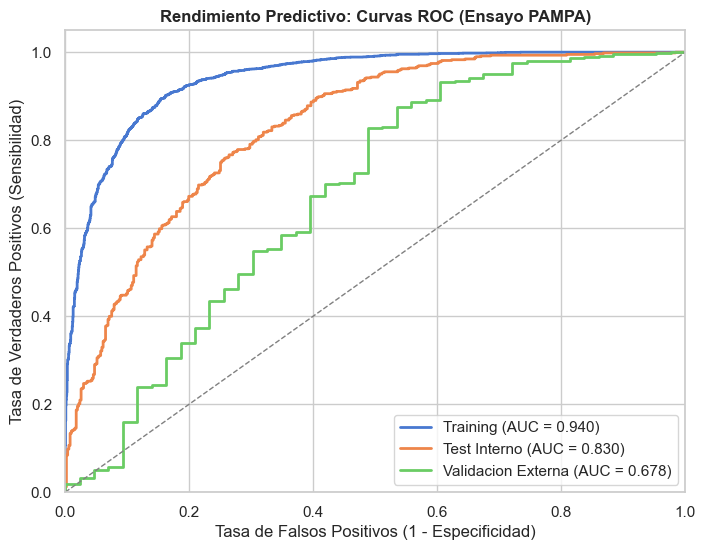

Grafico exportado con calidad de publicacion a: ../results/figures/Curvas_ROC_PAMPA.png


In [5]:
# ==============================================================================
# 7. Evaluacion Final del Modelo (Training, Test y Validacion Externa)
# ==============================================================================
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, matthews_corrcoef, f1_score, roc_curve
import matplotlib.pyplot as plt
import os

# 1. Funcion analitica para extraccion de metricas
def get_metrics(y_true, y_pred, y_prob, dataset_name):
    """
    Calcula las metricas de rendimiento emulando la precision, 
    sensibilidad y especificidad de un instrumento analitico.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Manejo de division por cero por seguridad
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    mcc = matthews_corrcoef(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        "Dataset": dataset_name,
        "Accuracy": acc,
        "Sensibilidad": sens,
        "Especificidad": spec,
        "AUC": auc,
        "MCC": mcc,
        "F1-Score": f1
    }

# 2. Recoleccion de muestras (Predicciones)
metricas = []

# Training (Para diagnosticar posible sobreajuste / overfitting)
metricas.append(get_metrics(y_train, best_rf.predict(X_train), best_rf.predict_proba(X_train)[:,1], "Training (Original)"))

# Test Interno
metricas.append(get_metrics(y_test, best_rf.predict(X_test), best_rf.predict_proba(X_test)[:,1], "Test Interno"))

# Validacion Externa (La prueba de fuego de nuestro modelo)
metricas.append(get_metrics(y_ext, best_rf.predict(X_ext), best_rf.predict_proba(X_ext)[:,1], "Validacion Externa"))

# 3. Consolidacion y presentacion de resultados
df_metrics = pd.DataFrame(metricas).set_index("Dataset").round(3)
print("--- Tabla de Rendimiento ---")
display(df_metrics)

# Exportacion de la libreta de resultados
metricas_path = "../results/metrics/evaluacion_final_datasets.csv"
df_metrics.to_csv(metricas_path)
print(f"\nReporte analitico exportado fisicamente a: {metricas_path}")

# ==============================================================================
# 8. Visualizacion: Curvas ROC Superpuestas
# ==============================================================================
print("\nGenerando grafico de diagnostico ROC...")

plt.figure(figsize=(8, 6))

# Iteramos sobre los tres conjuntos para superponer sus curvas
conjuntos = [
    (X_train, y_train, "Training"),
    (X_test, y_test, "Test Interno"),
    (X_ext, y_ext, "Validacion Externa")
]

for X, y, label in conjuntos:
    y_prob = best_rf.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc_score = roc_auc_score(y, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {auc_score:.3f})')

# Linea de clasificador aleatorio (peor escenario)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Estetica del grafico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Rendimiento Predictivo: Curvas ROC (Ensayo PAMPA)', fontweight='bold')
plt.legend(loc="lower right")

# Guardamos la figura de alta calidad para GitHub/Tesis
roc_path = "../results/figures/Curvas_ROC_PAMPA.png"
plt.savefig(roc_path, bbox_inches='tight')
plt.show()

print(f"Grafico exportado con calidad de publicacion a: {roc_path}")

Generando panel de Matrices de Confusion...


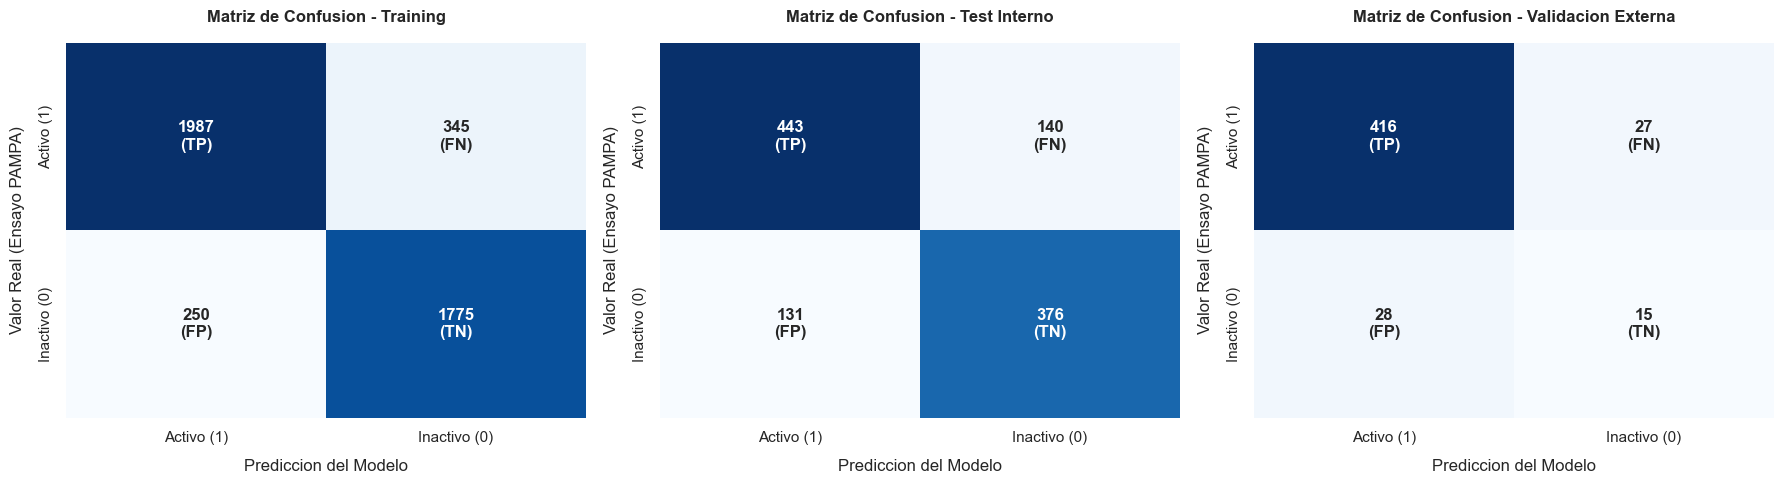

Matriz exportada a: ../results/figures\Matrices_Confusion_PAMPA.png

Generando Curvas ROC...


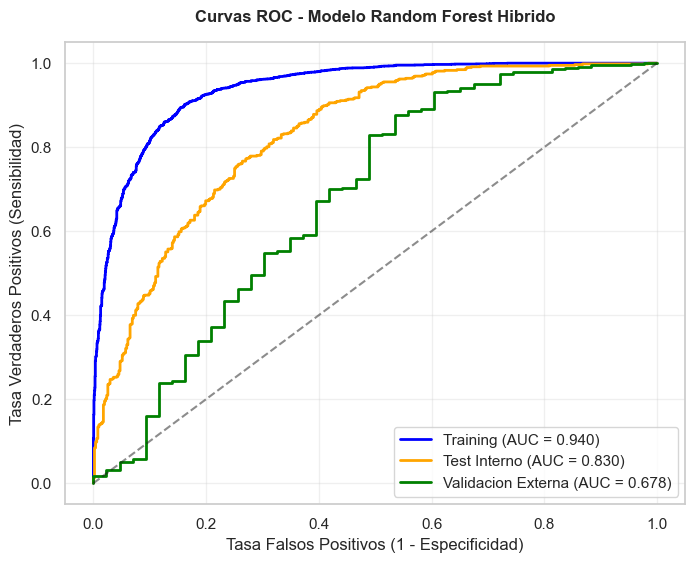

Curvas ROC exportadas a: ../results/figures\Curvas_ROC_Hibrido_PAMPA.png


In [6]:
# ==============================================================================
# 8. Visualizaciones
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import os

# Aseguramos que el directorio de figuras exista
figures_dir = "../results/figures"
os.makedirs(figures_dir, exist_ok=True)

# ------------------------------------------------------------------------------
# 8.1 Panel de Matrices de Confusion
# ------------------------------------------------------------------------------
print("Generando panel de Matrices de Confusion...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista de datos a graficar (Nuestros 3 escenarios analiticos)
datasets = [
    (y_train, best_rf.predict(X_train), "Training"), 
    (y_test, best_rf.predict(X_test), "Test Interno"), 
    (y_ext, best_rf.predict(X_ext), "Validacion Externa")
]

for i, (y_true, y_pred, title) in enumerate(datasets):
    # Forzamos que el 1 (Activo) sea la primera fila/columna
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    
    # Extraemos valores: TP, FN, FP, TN
    tp, fn, fp, tn = cm.ravel()
    
    # Etiquetas enriquecidas
    box_labels = np.array([
        [f"{tp}\n(TP)", f"{fn}\n(FN)"],
        [f"{fp}\n(FP)", f"{tn}\n(TN)"]
    ])

    sns.heatmap(cm, annot=box_labels, fmt="", cmap="Blues", cbar=False, ax=axes[i],
                annot_kws={"size": 12, "weight": "bold"})
    
    axes[i].set_title(f"Matriz de Confusion - {title}", fontweight='bold', pad=15)
    axes[i].set_xlabel("Prediccion del Modelo", labelpad=10)
    axes[i].set_ylabel("Valor Real (Ensayo PAMPA)", labelpad=10)
    axes[i].set_xticklabels(['Activo (1)', 'Inactivo (0)'])
    axes[i].set_yticklabels(['Activo (1)', 'Inactivo (0)'])

plt.tight_layout()
cm_path = os.path.join(figures_dir, "Matrices_Confusion_PAMPA.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Matriz exportada a: {cm_path}")

# ------------------------------------------------------------------------------
# 8.2 Curvas ROC Superpuestas
# ------------------------------------------------------------------------------
print("\nGenerando Curvas ROC...")

plt.figure(figsize=(8, 6))

# Agregue tu set de Validacion Externa que faltaba en el bucle original
roc_datasets = [
    (X_train, y_train, 'Training', 'blue'), 
    (X_test, y_test, 'Test Interno', 'orange'),
    (X_ext, y_ext, 'Validacion Externa', 'green')
]

for X, y, label, color in roc_datasets:
    y_prob = best_rf.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", color=color, linewidth=2)

# Linea de clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel('Tasa Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC - Modelo Random Forest Hibrido', fontweight='bold', pad=15)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

roc_path = os.path.join(figures_dir, "Curvas_ROC_Hibrido_PAMPA.png")
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Curvas ROC exportadas a: {roc_path}")


Calculando el peso analitico de los descriptores quimicos...


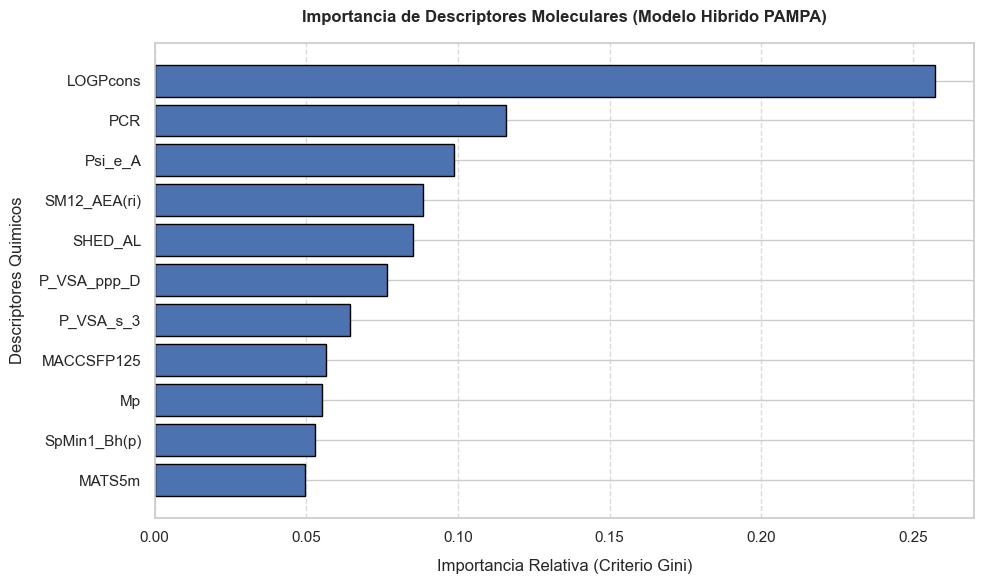

Analisis de variables exportado con calidad de publicacion a: ../results/figures/Importancia_Variables_PAMPA.png


In [7]:
# ==============================================================================
# 9. Analisis de Importancia de Variables (Feature Importance)
# ==============================================================================
print("\nCalculando el peso analitico de los descriptores quimicos...")

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Extraemos los nombres dinamicamente de las columnas del set de entrenamiento
names = [X_train.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Importancia de Descriptores Moleculares (Modelo Hibrido PAMPA)", fontweight='bold', pad=15)

# Graficamos con un toque estetico profesional
plt.barh(range(X_train.shape[1]), importances[indices], align="center", color="#4c72b0", edgecolor='black')
plt.yticks(range(X_train.shape[1]), names)
plt.gca().invert_yaxis() # Para que el descriptor mas importante quede arriba

plt.xlabel("Importancia Relativa (Criterio Gini)", labelpad=10)
plt.ylabel("Descriptores Quimicos", labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

# Exportacion de la figura
importances_path = "../results/figures/Importancia_Variables_PAMPA.png"
plt.savefig(importances_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Analisis de variables exportado con calidad de publicacion a: {importances_path}")



Iniciando analisis de interpretabilidad mecanistica (SHAP)...
-> Formato de array 3D detectado. Aislando el impacto para la clase 'Activa' (1).
Dimensiones X_test: (1090, 11) | Dimensiones SHAP: (1090, 11)


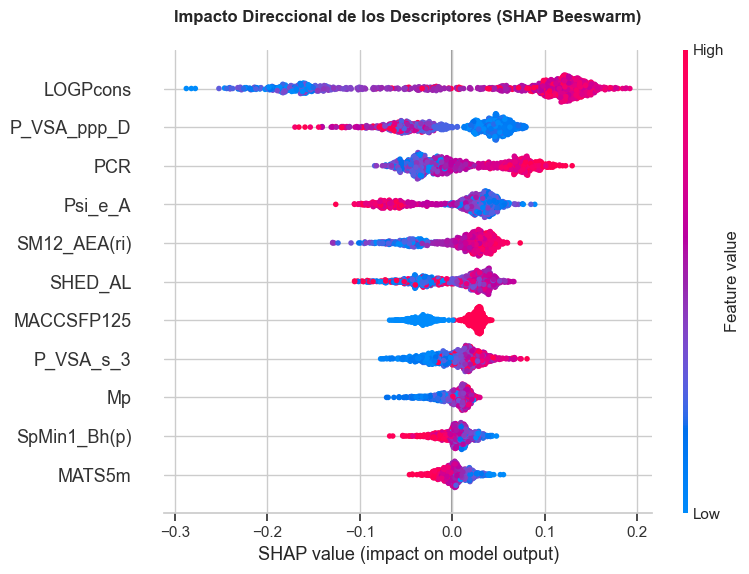

Grafico SHAP Beeswarm exportado a: ../results/figures\SHAP_Beeswarm_PAMPA.png


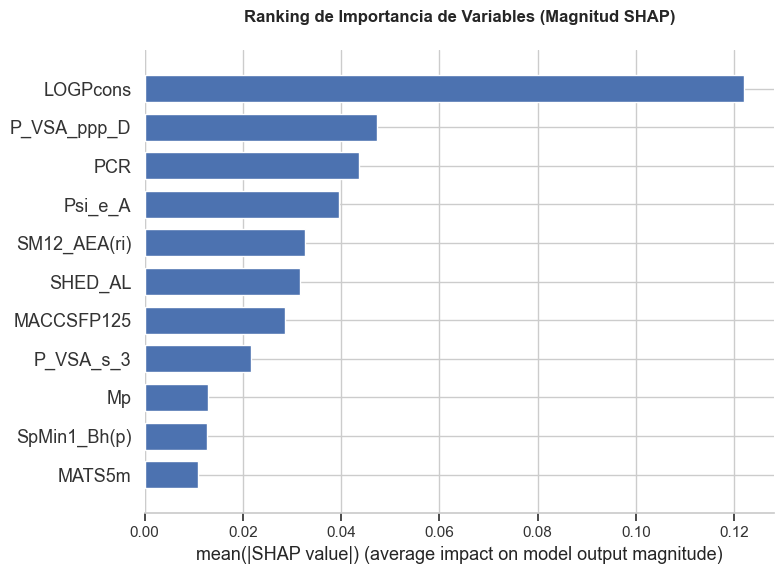

Grafico SHAP Bar exportado a: ../results/figures\SHAP_Bar_PAMPA.png


In [8]:
# ==============================================================================
# 10. Interpretabilidad del Modelo Avanzada (Analisis SHAP)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

print("\nIniciando analisis de interpretabilidad mecanistica (SHAP)...")

# 1. Definicion del Explicador (Nuestro espectrometro virtual)
explainer = shap.TreeExplainer(best_rf)

# 2. Calculo de valores SHAP sobre el set de prueba
# check_additivity=False evita errores de redondeo computacional en ensambles grandes
shap_values = explainer.shap_values(X_test, check_additivity=False)

# 3. Correccion automatica de formato dimensional (Depende de la version de la libreria)
vals_a_graficar = None

if isinstance(shap_values, list):
    print("-> Formato de lista detectado. Aislando el impacto para la clase 'Activa' (1).")
    vals_a_graficar = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("-> Formato de array 3D detectado. Aislando el impacto para la clase 'Activa' (1).")
    vals_a_graficar = shap_values[:, :, 1]
else:
    print("-> Formato de array 2D detectado. Utilizando valores directos.")
    vals_a_graficar = shap_values

# 4. Validacion de integridad dimensional antes de graficar
print(f"Dimensiones X_test: {X_test.shape} | Dimensiones SHAP: {vals_a_graficar.shape}")

if X_test.shape == vals_a_graficar.shape:
    figures_dir = "../results/figures"
    
    # 5. Visualizacion Global (Beeswarm Plot - Impacto Direccional)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(vals_a_graficar, X_test, show=False)
    plt.title("Impacto Direccional de los Descriptores (SHAP Beeswarm)", fontweight='bold', pad=20)
    plt.tight_layout()
    
    shap_beeswarm_path = os.path.join(figures_dir, "SHAP_Beeswarm_PAMPA.png")
    plt.savefig(shap_beeswarm_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico SHAP Beeswarm exportado a: {shap_beeswarm_path}")

    # 6. Visualizacion de Barras (Ranking Absoluto SHAP)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(vals_a_graficar, X_test, plot_type="bar", show=False, color="#4c72b0")
    plt.title("Ranking de Importancia de Variables (Magnitud SHAP)", fontweight='bold', pad=20)
    plt.tight_layout()
    
    shap_bar_path = os.path.join(figures_dir, "SHAP_Bar_PAMPA.png")
    plt.savefig(shap_bar_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Grafico SHAP Bar exportado a: {shap_bar_path}")

else:
    print("\nERROR CRITICO: Las dimensiones de la matriz no coinciden.")
    print("Causa probable: Diferencia de columnas entre X_train y X_test.")